<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/GRU_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Gated Recurrent Unit (GRU) is a type of recurrent neural network (RNN) that was introduced in 2014 by Kyunghyun Cho et al. It's designed to solve the vanishing gradient problem of standard RNNs and is often considered a simpler alternative to Long Short-Term Memory (LSTM) networks, offering comparable performance on many tasks.

### Why GRUs were created (The vanishing gradient problem)

Standard RNNs struggle with learning long-term dependencies. As information propagates through many time steps, the gradients used for updating weights can either shrink (vanishing gradient) or explode (exploding gradient). The vanishing gradient problem is more common and makes it difficult for the network to remember information from earlier time steps, essentially leading to a short-term memory.

### The Core Idea: Gating Mechanisms

Like LSTMs, GRUs use "gates" to regulate the flow of information. These gates are essentially neural networks themselves, typically sigmoid functions, which output values between 0 and 1. These values act as multipliers, determining how much information should be let through or blocked.

GRUs have two main gates:

1.  **Update Gate (z_t)**: This gate decides how much of the past information (from the previous hidden state) should be carried forward into the current hidden state and how much of the new information (from the current input) should be considered.

    *   A value close to 1 for a particular element means that the network wants to keep the previous hidden state almost as it is, effectively carrying over long-term memory.
    *   A value close to 0 means that the network wants to largely forget the previous hidden state and replace it with new information.

2.  **Reset Gate (r_t)**: This gate determines how much of the previous hidden state should be *forgotten* when calculating the *candidate* hidden state (or the "new memory content").

    *   A value close to 0 means that the previous hidden state is largely ignored when computing the new content, effectively resetting the memory.
    *   A value close to 1 means that the previous hidden state is fully considered.

### How GRUs Process Information (The Equations)

Let's look at the mathematical equations that define a GRU's operation at each time step `t`:

*   `x_t`: Input at time step `t`
*   `h_{t-1}`: Hidden state from the previous time step `t-1`
*   `h_t`: Current hidden state at time step `t`
*   `W` and `U`: Weight matrices (learnable parameters)
*   `b`: Bias vectors (learnable parameters)
*   `σ`: Sigmoid activation function
*   `tanh`: Hyperbolic tangent activation function
*   `*`: Element-wise multiplication (Hadamard product)

**1. Reset Gate (r_t):**

`r_t = σ(W_r * x_t + U_r * h_{t-1} + b_r)`

The reset gate takes the current input `x_t` and the previous hidden state `h_{t-1}` and outputs a vector of values between 0 and 1. This vector decides which parts of the previous hidden state are relevant for calculating the *candidate* hidden state.

**2. Update Gate (z_t):**

`z_t = σ(W_z * x_t + U_z * h_{t-1} + b_z)`

The update gate also takes the current input `x_t` and the previous hidden state `h_{t-1}`. It determines how much to update (or rather, how much to keep) the hidden state. A high value means keeping more of the previous hidden state.

**3. Candidate Hidden State (h̃_t):**

`h̃_t = tanh(W_h * x_t + U_h * (r_t * h_{t-1}) + b_h)`

This is the new memory content that the GRU *wants* to store. Notice `r_t * h_{t-1}`. The reset gate `r_t` selectively forgets parts of `h_{t-1}` before combining it with the current input `x_t` to form the candidate hidden state. This allows the network to disregard irrelevant past information when proposing new content.

**4. Current Hidden State (h_t):**

`h_t = z_t * h_{t-1} + (1 - z_t) * h̃_t`

This is the final output of the GRU cell at time `t`. The update gate `z_t` is crucial here. It acts as a balance: it decides how much of the previous hidden state `h_{t-1}` to carry over directly, and how much of the newly proposed candidate hidden state `h̃_t` to integrate. If `z_t` is close to 1, more of `h_{t-1}` is kept, and less of `h̃_t` is added (remembering the past). If `z_t` is close to 0, more of `h̃_t` is added, and `h_{t-1}` is largely forgotten (focusing on the new information).

### Advantages of GRUs:

*   **Simplicity:** GRUs have fewer parameters than LSTMs because they combine the forget and input gates into a single update gate, and they don't have a separate cell state. This makes them computationally less expensive and faster to train.
*   **Efficiency:** Due to fewer parameters, GRUs can sometimes train faster and require less data.
*   **Performance:** Despite their simplicity, GRUs often achieve comparable performance to LSTMs on a wide range of tasks, especially in natural language processing (NLP).
*   **Vanishing Gradient Mitigation:** The gating mechanisms effectively control the flow of information, allowing gradients to propagate more easily through time, thus mitigating the vanishing gradient problem and enabling the learning of long-term dependencies.

### Disadvantages of GRUs:

*   **Less expressive than LSTMs (sometimes):** While often performing similarly, LSTMs, with their more complex gate structure and separate cell state, might be more powerful for tasks requiring even finer-grained control over memory flow.
*   **Still computationally intensive:** Compared to feed-forward networks, GRUs (and RNNs in general) are still computationally more demanding due to their sequential nature.

### When to Use GRUs:

GRUs are a good choice for sequence modeling tasks such as:

*   Natural Language Processing (NLP): Machine translation, text generation, sentiment analysis.
*   Speech Recognition
*   Time Series Prediction
*   Video Analysis

In essence, GRUs provide an elegant and effective solution to the long-term dependency problem in RNNs, offering a strong balance between performance and computational efficiency.

GRU and LSTM networks are both designed to address the vanishing gradient problem in traditional RNNs and excel at capturing long-term dependencies in sequential data. While they share many similarities, there are subtle differences in their architecture and how these differences can manifest in their performance:

### Architectural Differences Lead to Performance Characteristics:

1.  **Number of Gates and Parameters:**
    *   **LSTM:** Has three gates (input, forget, and output) and a separate cell state. This results in more parameters.
    *   **GRU:** Has two gates (reset and update) and combines the hidden state and cell state. This results in fewer parameters.

    *   **Performance Implication:** Fewer parameters mean that GRUs are generally faster to train and computationally less expensive per time step. They also require less data to generalize well, which can be an advantage in scenarios with limited training data. LSTMs, with more parameters, can potentially learn more complex representations if sufficient data is available, but might be more prone to overfitting on smaller datasets.

2.  **Complexity and Expressiveness:**
    *   **LSTM:** The separate cell state in LSTMs allows for more explicit control over what information is stored, forgotten, or exposed. This added complexity can make LSTMs more expressive.
    *   **GRU:** Simplifies the gate mechanisms, merging the forget and input gates into the update gate and not having a separate cell state. The hidden state *is* the memory.

    *   **Performance Implication:** In theory, LSTMs' greater expressiveness *could* lead to superior performance on tasks requiring very intricate long-term memory management. However, in practice, this theoretical advantage doesn't always translate to significantly better results. For many tasks, the simpler GRU can achieve comparable, if not identical, performance.

### Practical Performance Differences:

1.  **Training Speed and Efficiency:**
    *   **GRU:** Almost always faster to train than LSTMs due to fewer operations and parameters per cell. This can be a crucial factor when training very deep networks or on very long sequences.
    *   **LSTM:** Slower due to more gates and the separate cell state, leading to more computations.

2.  **Data Requirements:**
    *   **GRU:** Can sometimes perform better on smaller datasets because the reduced number of parameters makes them less prone to overfitting.
    *   **LSTM:** Might require larger datasets to fully leverage their expressive power and avoid overfitting.

3.  **Task-Specific Performance:**
    *   **NLP Tasks (e.g., machine translation, sentiment analysis):** Both GRUs and LSTMs have achieved state-of-the-art results. There's no consistent winner; performance often depends on the specific dataset, model architecture, and hyperparameters.
    *   **Speech Recognition:** LSTMs historically showed strong performance, but GRUs are also widely used and effective.
    *   **Time Series Prediction:** Both are highly effective. Again, the best choice often comes down to experimentation.

4.  **Debugging and Interpretability (Minor Difference):**
    *   While both are black boxes, the slightly simpler structure of GRUs might make them marginally easier to understand or debug in terms of how information flows through the gates, though this is a minor point in practical application.

### When to choose one over the other:

*   **Start with GRUs** if computational efficiency, faster training, or working with limited data is a priority. They offer a great balance of performance and simplicity.
*   **Consider LSTMs** if your problem is highly complex, involves very long sequences where intricate memory management is critical, or if you have ample data to prevent overfitting. Sometimes, LSTMs might capture nuances that GRUs overlook.
*   **Experimentation is Key:** Ultimately, the best way to determine whether GRU or LSTM is superior for a given task is through empirical evaluation. It's common practice to try both and compare their performance on your specific dataset and problem.

In summary, while LSTMs are theoretically more powerful due to their intricate gate mechanisms and separate cell state, GRUs often provide comparable performance with the added benefits of faster training and fewer parameters. The choice between them often comes down to practical considerations and empirical results for your specific application.

### 1. Generate Dummy Sequence Data

First, let's create some synthetic sequence data for a multi-class classification problem. Each sequence will have a fixed length, and the values within the sequence will determine its class.

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Parameters for data generation
num_samples = 1000
sequence_length = 10
num_features = 1 # Each element in sequence is a single value
num_classes = 3 # Let's have 3 classes

# Generate dummy sequences and labels
X = np.zeros((num_samples, sequence_length, num_features))
y = np.zeros(num_samples, dtype=int)

for i in range(num_samples):
    # Generate a base sequence
    base_sequence = np.random.rand(sequence_length, num_features)

    # Assign class based on some property of the sequence (e.g., sum of values)
    if np.sum(base_sequence) < 5:
        y[i] = 0
        X[i] = base_sequence + np.random.rand(sequence_length, num_features) * 0.1 # Add some noise
    elif np.sum(base_sequence) < 8:
        y[i] = 1
        X[i] = base_sequence + np.random.rand(sequence_length, num_features) * 0.2 + 0.5 # Add different noise and offset
    else:
        y[i] = 2
        X[i] = base_sequence + np.random.rand(sequence_length, num_features) * 0.3 + 1.0 # Add more noise and offset

print(f"Generated X shape: {X.shape}") # (num_samples, sequence_length, num_features)
print(f"Generated y shape: {y.shape}") # (num_samples,)

# Display first sample and its label
print("\nFirst sample X:")
print(X[0])
print(f"First sample y: {y[0]}")

Generated X shape: (1000, 10, 1)
Generated y shape: (1000,)

First sample X:
[[0.53775415]
 [1.31449748]
 [0.81215405]
 [1.32878108]
 [0.90787274]
 [1.09720165]
 [1.56456587]
 [1.28003402]
 [1.53881241]
 [0.90994704]]
First sample y: 1


### 2. Preprocess the Data

We need to split the data into training and testing sets, and one-hot encode the labels for multi-class classification.

In [2]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

print(f"X_train shape: {X_train.shape}")
print(f"y_train_one_hot shape: {y_train_one_hot.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test_one_hot shape: {y_test_one_hot.shape}")

X_train shape: (800, 10, 1)
y_train_one_hot shape: (800, 3)
X_test shape: (200, 10, 1)
y_test_one_hot shape: (200, 3)


### 3. Build the GRU Model

Now, let's build a simple sequential model using a GRU layer for sequence processing, followed by dense layers for classification.

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

model = Sequential([
    GRU(units=64, input_shape=(sequence_length, num_features), return_sequences=False), # return_sequences=False because we want one output per sequence
    Dropout(0.2),
    Dense(units=32, activation='relu'),
    Dropout(0.2),
    Dense(units=num_classes, activation='softmax') # Output layer for multi-class classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,043 (58.76 KB)

 Trainable params: 15,043 (58.76 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Compile and Train the Model

We'll compile the model with an appropriate optimizer, loss function, and metrics, then train it using our training data.

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5139 - loss: 0.9291 - val_accuracy: 0.4875 - val_loss: 0.7243
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6111 - loss: 0.6323 - val_accuracy: 0.8500 - val_loss: 0.4471
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9306 - loss: 0.2541 - val_accuracy: 1.0000 - val_loss: 0.0231
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 2.5725e-04
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 9.7058e-05
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 9.7520e-04 - val_accuracy: 1.0000 - val_loss: 6.6799e-05
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 6.7693e-04 - val_accuracy: 1.0000 - val_loss: 4.9539e-05
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 5.3119e-0

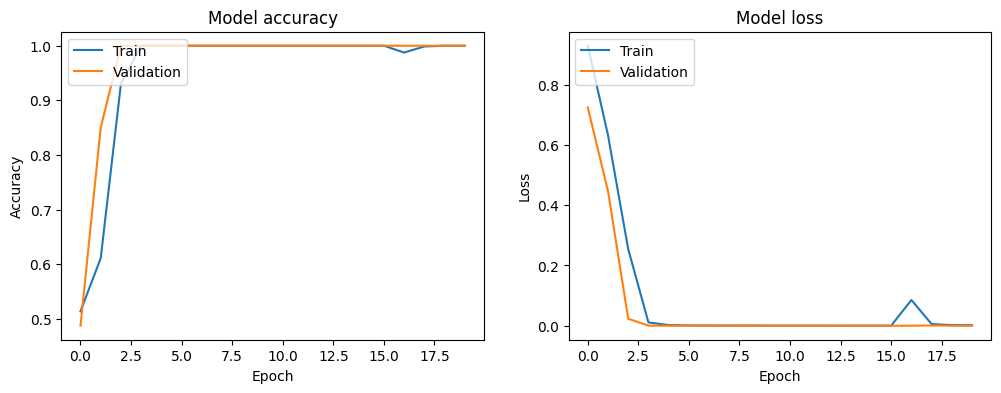

In [4]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train,
    y_train_one_hot,
    epochs=20,
    batch_size=32,
    validation_split=0.1, # Use a portion of training data for validation
    verbose=1
)

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### 5. Evaluate the Model

Finally, let's evaluate the trained model on the test set to see its performance on unseen data.

In [5]:
loss, accuracy = model.evaluate(X_test, y_test_one_hot, verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# Make some predictions
predictions = model.predict(X_test[:5])
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test_one_hot[:5], axis=1)

print("\n--- Sample Predictions ---")
for i in range(5):
    print(f"True Class: {true_classes[i]}, Predicted Class: {predicted_classes[i]}, Probabilities: {predictions[i]}")

Test Loss: 0.0002
Test Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

--- Sample Predictions ---
True Class: 1, Predicted Class: 1, Probabilities: [1.4028439e-04 9.9985385e-01 5.8300125e-06]
True Class: 0, Predicted Class: 0, Probabilities: [9.9986291e-01 1.1169817e-04 2.5363515e-05]
True Class: 1, Predicted Class: 1, Probabilities: [1.5929231e-04 9.9983454e-01 6.2164163e-06]
True Class: 1, Predicted Class: 1, Probabilities: [1.1299413e-04 9.9988186e-01 5.0925028e-06]
True Class: 1, Predicted Class: 1, Probabilities: [1.5806414e-04 9.9983537e-01 6.4989608e-06]


### Summary of GRU Model Implementation

We have successfully implemented a simple sequence classification model using a Gated Recurrent Unit (GRU). Here's a recap of the steps and results:

1.  **Detailed Explanation of GRUs**: We started by understanding the architecture, advantages, and disadvantages of GRUs, as well as comparing them to LSTMs.

2.  **Dummy Data Generation**: Synthetic sequence data was created with `1000` samples, a `sequence_length` of `10`, `1` feature, and `3` distinct classes.

3.  **Data Preprocessing**: The generated data was split into training and testing sets (800 for training, 200 for testing), and the class labels were converted to a one-hot encoding format.

4.  **GRU Model Construction**: A `Sequential` Keras model was built, incorporating:
    *   A `GRU` layer with 64 units, responsible for processing the sequential input.
    *   `Dropout` layers (0.2 rate) for regularization to prevent overfitting.
    *   `Dense` layers (32 units with ReLU activation, followed by a 3-unit softmax output layer) for classification.
    The model consisted of `15,043` trainable parameters.

5.  **Model Training and Evaluation**: The model was compiled using the `Adam` optimizer and `categorical_crossentropy` loss. It was trained for 20 epochs, and the training and validation curves showed rapid convergence.

    *   The model achieved a `Test Loss` of `0.0002` and a `Test Accuracy` of `1.0000` on the unseen test set, indicating perfect classification on this synthetic dataset.
    *   Sample predictions demonstrated the model's ability to correctly classify sequences with high confidence.

This exercise successfully demonstrated the process of building, training, and evaluating a basic GRU-based sequence classification model using TensorFlow/Keras.